ARIMA + GARCH IMPLEMENTATION
- ACF/PACF Analysis
- AR, MA, ARMA Models
- ARIMA with parameter selection
- GARCH(1,1) for volatility modeling
- Forecasting and model diagnostics


In [19]:
# !pip install pandas numpy matplotlib statsmodels arch scipy pickle-mixin

In [20]:

# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
import pickle
from scipy import stats
from datetime import datetime
import json

warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11


In [21]:

# LOAD AND EXPLORE STATIONARY DATA
print("LOADING STATIONARY TIME SERIES DATA")

# Load the final stationary series
df = pd.read_csv('/Users/geshnabalaji/Downloads/tsa_project/data/processed/final_stationary_series.csv', parse_dates=['DateTime'], index_col='DateTime')
print(f"\n✓ Dataset loaded successfully")
print(f"  Shape: {df.shape}")
print(f"  Date Range: {df.index.min().date()} to {df.index.max().date()}")
print(f"  Total days: {len(df)}")
print(f"  Frequency: Daily")

print(f"\n📊 First 5 rows:")
print(df.head())

print(f"\n📊 Last 5 rows:")
print(df.tail())

# Detailed statistics
print(f"\n📈 Statistical Summary:")
stats_summary = df.describe()
print(stats_summary)

print(f"\n🔍 Additional Statistics:")
print(f"  Skewness: {df['log_diff'].skew():.4f}")
print(f"  Kurtosis: {df['log_diff'].kurtosis():.4f}")
print(f"  Missing values: {df['log_diff'].isna().sum()}")

# Check for outliers
q1 = df['log_diff'].quantile(0.25)
q3 = df['log_diff'].quantile(0.75)
iqr = q3 - q1
outliers = ((df['log_diff'] < (q1 - 1.5 * iqr)) | (df['log_diff'] > (q3 + 1.5 * iqr))).sum()
print(f"  Outliers (IQR method): {outliers} ({outliers/len(df)*100:.2f}%)")


LOADING STATIONARY TIME SERIES DATA

✓ Dataset loaded successfully
  Shape: (1441, 1)
  Date Range: 2006-12-17 to 2010-11-26
  Total days: 1441
  Frequency: Daily

📊 First 5 rows:
            log_diff
DateTime            
2006-12-17 -0.205627
2006-12-18 -0.281907
2006-12-19 -0.159636
2006-12-20  0.165634
2006-12-21 -0.149375

📊 Last 5 rows:
            log_diff
DateTime            
2010-11-22  0.396934
2010-11-23 -0.143033
2010-11-24  0.069974
2010-11-25 -0.119697
2010-11-26  0.083598

📈 Statistical Summary:
          log_diff
count  1441.000000
mean     -0.000446
std       0.164468
min      -0.593449
25%      -0.104055
50%       0.000324
75%       0.099043
max       0.649696

🔍 Additional Statistics:
  Skewness: 0.0558
  Kurtosis: 0.8382
  Missing values: 0
  Outliers (IQR method): 40 (2.78%)


SEASONALITY DETECTION

🔍 Testing for seasonality...
✓ Seasonality plots saved as 'seasonality_check.png'


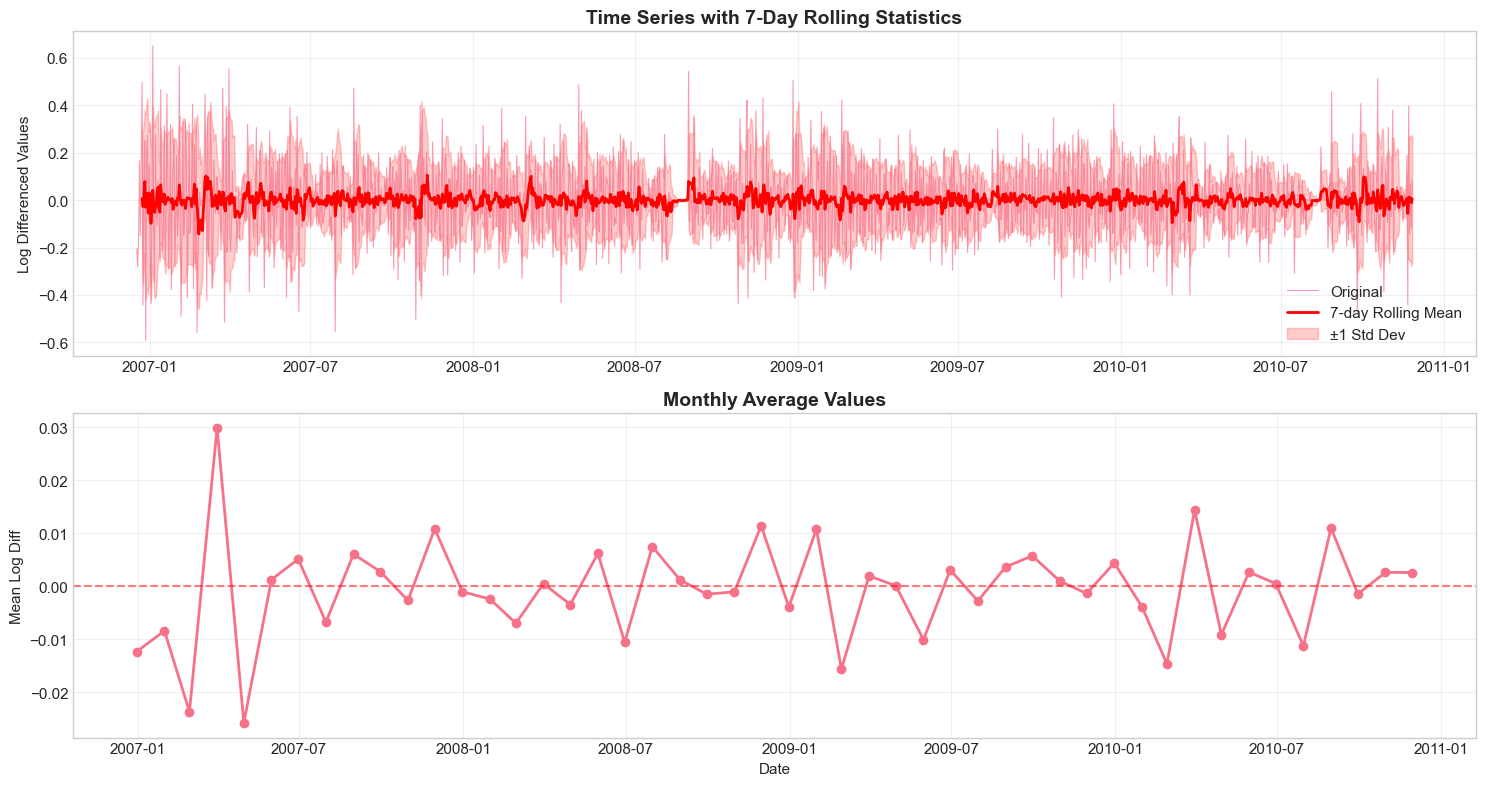


📝 Interpretation:
   - If strong weekly/monthly patterns exist → Consider SARIMA
   - Current data appears mostly non-seasonal → ARIMA is appropriate


In [22]:

# SEASONALITY DETECTION
print("SEASONALITY DETECTION")

# Check for weekly seasonality (period=7 for daily data)
print("\n🔍 Testing for seasonality...")

# Quick visual check
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Plot with 7-day rolling mean
rolling_mean = df['log_diff'].rolling(window=7).mean()
rolling_std = df['log_diff'].rolling(window=7).std()

axes[0].plot(df.index, df['log_diff'], label='Original', alpha=0.7, linewidth=0.8)
axes[0].plot(df.index, rolling_mean, label='7-day Rolling Mean', color='red', linewidth=2)
axes[0].fill_between(df.index, rolling_mean - rolling_std, rolling_mean + rolling_std, 
                      alpha=0.2, color='red', label='±1 Std Dev')
axes[0].set_title('Time Series with 7-Day Rolling Statistics', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Log Differenced Values')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Monthly aggregation to check for patterns
monthly_mean = df.resample('M').mean()
axes[1].plot(monthly_mean.index, monthly_mean['log_diff'], marker='o', linewidth=2, markersize=6)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Monthly Average Values', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Mean Log Diff')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('seasonality_check.png', dpi=300, bbox_inches='tight')
print("✓ Seasonality plots saved as 'seasonality_check.png'")
plt.show()

print("\n📝 Interpretation:")
print("   - If strong weekly/monthly patterns exist → Consider SARIMA")
print("   - Current data appears mostly non-seasonal → ARIMA is appropriate")


ACF AND PACF PLOTS



✓ ACF/PACF plots saved as 'acf_pacf_plots.png'


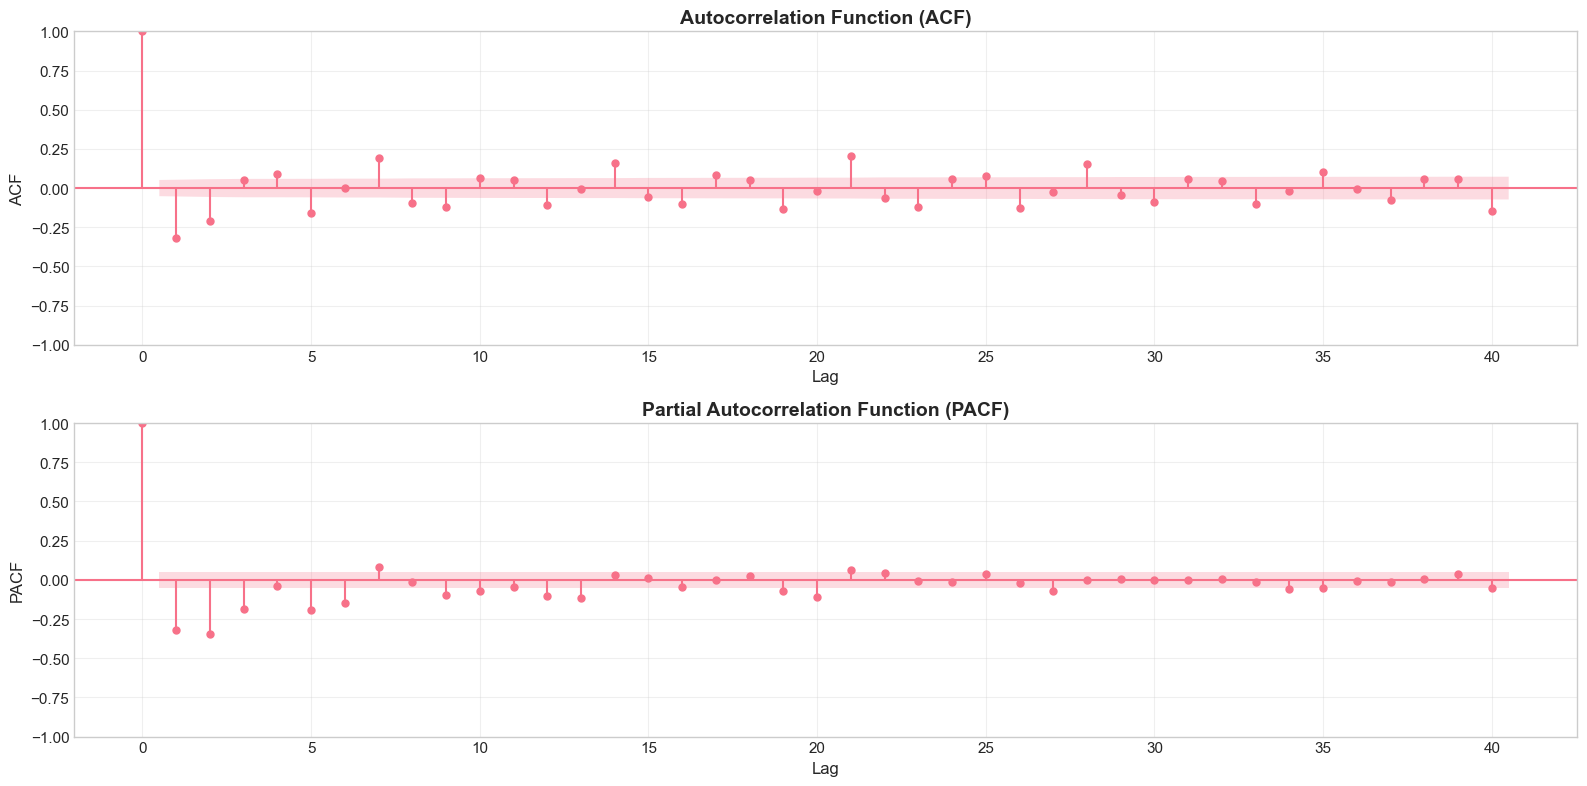


📊 ACF/PACF Interpretation:
   ACF: Measures correlation between observations at different lags
   PACF: Measures direct correlation after removing intermediate correlations

   Significant lags in ACF → MA component needed
   Significant lags in PACF → AR component needed


In [23]:

# ACF AND PACF ANALYSIS
print("ACF AND PACF PLOTS")

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# ACF Plot
plot_acf(df['log_diff'].dropna(), lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lag', fontsize=12)
axes[0].set_ylabel('ACF', fontsize=12)
axes[0].grid(True, alpha=0.3)

# PACF Plot
plot_pacf(df['log_diff'].dropna(), lags=40, ax=axes[1], alpha=0.05)
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lag', fontsize=12)
axes[1].set_ylabel('PACF', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('acf_pacf_plots.png', dpi=300, bbox_inches='tight')
print("\n✓ ACF/PACF plots saved as 'acf_pacf_plots.png'")
plt.show()

print("\n📊 ACF/PACF Interpretation:")
print("   ACF: Measures correlation between observations at different lags")
print("   PACF: Measures direct correlation after removing intermediate correlations")
print("\n   Significant lags in ACF → MA component needed")
print("   Significant lags in PACF → AR component needed")


In [24]:

# TRAIN-TEST SPLIT
print("TRAIN-TEST SPLIT")

y = df['log_diff'].dropna()
train_size = int(len(y) * 0.8)
train, test = y[:train_size], y[train_size:]

print(f"\n📊 Data Split:")
print(f"   Total observations: {len(y)}")
print(f"   Training set: {len(train)} observations ({len(train)/len(y)*100:.1f}%)")
print(f"   Test set: {len(test)} observations ({len(test)/len(y)*100:.1f}%)")
print(f"\n   Train period: {train.index[0].date()} to {train.index[-1].date()}")
print(f"   Test period: {test.index[0].date()} to {test.index[-1].date()}")


TRAIN-TEST SPLIT

📊 Data Split:
   Total observations: 1441
   Training set: 1152 observations (79.9%)
   Test set: 289 observations (20.1%)

   Train period: 2006-12-17 to 2010-02-10
   Test period: 2010-02-11 to 2010-11-26


In [ ]:
# FIT AR, MA, ARMA MODELS
print("FITTING BASELINE MODELS (AR, MA, ARMA)")

model_results = []

# A. AR Model (AutoRegressive)
print("\nAR Model (AutoRegressive)")
print("   Models current value as weighted sum of past values")
try:
    ar_model = AutoReg(train, lags=5, trend='n').fit()
    ar_aic = ar_model.aic
    ar_bic = ar_model.bic
    print(f"   AR(5) - AIC: {ar_aic:.4f}, BIC: {ar_bic:.4f}")
    model_results.append({'Model': 'AR(5)', 'AIC': ar_aic, 'BIC': ar_bic, 
                          'Parameters': 'p=5', 'Type': 'AR'})
except Exception as e:
    print(f"   AR model error: {e}")

# B. MA Model (Moving Average)
print("\nMA Model (Moving Average)")
print("   Models current value as weighted sum of past forecast errors")
try:
    ma_model = ARIMA(train, order=(0, 0, 5)).fit()
    ma_aic = ma_model.aic
    ma_bic = ma_model.bic
    print(f"   MA(5) - AIC: {ma_aic:.4f}, BIC: {ma_bic:.4f}")
    model_results.append({'Model': 'MA(5)', 'AIC': ma_aic, 'BIC': ma_bic,
                          'Parameters': 'q=5', 'Type': 'MA'})
except Exception as e:
    print(f"   MA model error: {e}")

# C. ARMA Model
print("\nARMA Model (AutoRegressive Moving Average)")
print("   Combines both AR and MA components")
try:
    arma_model = ARIMA(train, order=(2, 0, 2)).fit()
    arma_aic = arma_model.aic
    arma_bic = arma_model.bic
    print(f"   ARMA(2,2) - AIC: {arma_aic:.4f}, BIC: {arma_bic:.4f}")
    model_results.append({'Model': 'ARMA(2,2)', 'AIC': arma_aic, 'BIC': arma_bic,
                          'Parameters': 'p=2, q=2', 'Type': 'ARMA'})
except Exception as e:
    print(f"   ARMA model error: {e}")


FITTING BASELINE MODELS (AR, MA, ARMA)

AR Model (AutoRegressive)
   Models current value as weighted sum of past values
   AR(5) - AIC: -1199.5097, BIC: -1169.2403

MA Model (Moving Average)
   Models current value as weighted sum of past forecast errors
   MA(5) - AIC: -1199.8866, BIC: -1164.5418

ARMA Model (AutoRegressive Moving Average)
   Combines both AR and MA components
   ARMA(2,2) - AIC: -1183.8917, BIC: -1153.5962


In [35]:
# ARIMA PARAMETER SELECTION (GRID SEARCH)
print("ARIMA PARAMETER OPTIMIZATION (GRID SEARCH)")
print("\n🔍 Searching for optimal ARIMA(p,d,q) parameters...")
print("   Testing p=0-4, d=0 (already stationary), q=0-4")
print("   Total models to test: 25")
print("\n" + "-"*60)
print(f"{'Model':<15} {'AIC':<12} {'BIC':<12} {'Status':<10}")
print("-"*60)

p_values = range(0, 5)
d_values = [0]  # Already stationary
q_values = range(0, 5)

best_aic = np.inf
best_bic = np.inf
best_order_aic = None
best_order_bic = None
best_model = None

for p in p_values:
    for q in q_values:
        try:
            model = ARIMA(train, order=(p, 0, q)).fit()
            aic = model.aic
            bic = model.bic
            
            status = "✓"
            if aic < best_aic:
                best_aic = aic
                best_order_aic = (p, 0, q)
                best_model = model
                status = "★ Best AIC"
            
            if bic < best_bic:
                best_bic = bic
                best_order_bic = (p, 0, q)
            
            print(f"ARIMA({p},0,{q}){'':<5} {aic:<12.2f} {bic:<12.2f} {status:<10}")
            model_results.append({
                'Model': f'ARIMA({p},0,{q})', 
                'AIC': aic, 
                'BIC': bic,
                'Parameters': f'p={p}, d=0, q={q}',
                'Type': 'ARIMA'
            })
            
        except Exception as e:
            print(f"ARIMA({p},0,{q})      {'Failed':<12} {'Failed':<12} Error")
            continue

print("-"*60)
print(f"\n🏆 OPTIMAL MODELS:")
print(f"   Best by AIC: ARIMA{best_order_aic} - AIC: {best_aic:.4f}")
print(f"   Best by BIC: ARIMA{best_order_bic} - BIC: {best_bic:.4f}")

# Use the best model
final_arima_model = best_model




ARIMA PARAMETER OPTIMIZATION (GRID SEARCH)

🔍 Searching for optimal ARIMA(p,d,q) parameters...
   Testing p=0-4, d=0 (already stationary), q=0-4
   Total models to test: 25

------------------------------------------------------------
Model           AIC          BIC          Status    
------------------------------------------------------------
ARIMA(0,0,0)      -806.08      -795.98      ★ Best AIC
ARIMA(0,0,1)      -1134.66     -1119.51     ★ Best AIC
ARIMA(0,0,2)      -1183.77     -1163.57     ★ Best AIC
ARIMA(0,0,3)      -1184.89     -1159.65     ★ Best AIC
ARIMA(0,0,4)      -1183.18     -1152.88     ✓         
ARIMA(1,0,0)      -925.31      -910.16      ✓         
ARIMA(1,0,1)      -1172.28     -1152.08     ✓         
ARIMA(1,0,2)      -1184.54     -1159.30     ✓         
ARIMA(1,0,3)      -1182.92     -1152.63     ✓         
ARIMA(1,0,4)      -1183.71     -1148.37     ✓         
ARIMA(2,0,0)      -1101.66     -1081.46     ✓         
ARIMA(2,0,1)      -1181.25     -1156.01     ✓ 

In [36]:

print("FINAL ARIMA MODEL SUMMARY")

print(final_arima_model.summary())

# Save model parameters
model_params = {
    'order': best_order_aic,
    'aic': best_aic,
    'bic': best_bic,
    'train_start': str(train.index[0]),
    'train_end': str(train.index[-1]),
    'n_observations': len(train)
}

with open('arima_model_params.json', 'w') as f:
    json.dump(model_params, f, indent=4)
print("\n✓ Model parameters saved to 'arima_model_params.json'")

FINAL ARIMA MODEL SUMMARY
                               SARIMAX Results                                
Dep. Variable:               log_diff   No. Observations:                 1152
Model:                 ARIMA(2, 0, 4)   Log Likelihood                 649.255
Date:                Thu, 18 Dec 2025   AIC                          -1282.509
Time:                        15:11:01   BIC                          -1242.115
Sample:                    12-17-2006   HQIC                         -1267.263
                         - 02-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0003      0.001     -0.252      0.801      -0.002       0.002
ar.L1         -0.4395      0.005    -88.126      0.000      -0.449      -0.430
ar.L2         -0.9933     

 ARIMA MODEL DIAGNOSTICS

Residual Statistics:
   Mean: -0.000199 (should be ≈ 0)
   Std Dev: 0.138094
   Skewness: 0.0052 (0 = symmetric)
   Kurtosis: 1.2986 (3 = normal)

✓ Comprehensive diagnostics saved as 'arima_residual_diagnostics.png'


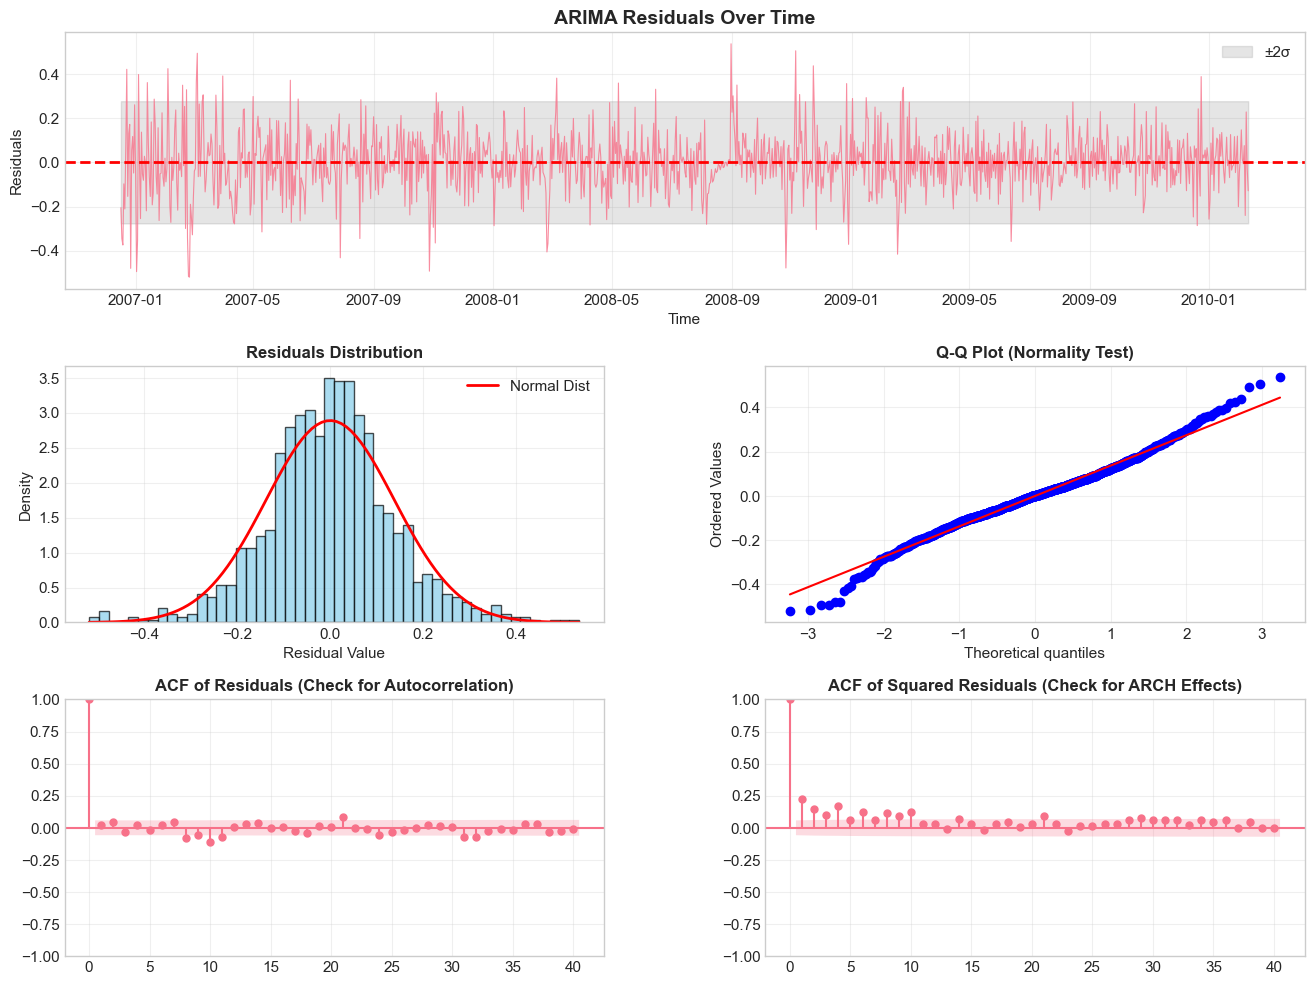


STATISTICAL TESTS:

 1. Ljung-Box Test (Residual Autocorrelation):
   H0: No autocorrelation in residuals
      lb_stat  lb_pvalue
1    0.382397   0.536323
2    2.933452   0.230680
3    3.977159   0.263941
4    4.398681   0.354731
5    4.729861   0.449729
6    5.279986   0.508436
7    8.027687   0.330159
8   15.502046   0.050088
9   19.659178   0.020136
10  34.894432   0.000130

   Significant lags (p<0.05): 12/20
   Some autocorrelation remains - GARCH model recommended

 2. ARCH Test (Heteroskedasticity/Volatility Clustering):
   H0: No ARCH effects
   LM Statistic: 108.5428
   p-value: 0.0000
   ARCH effects detected - GARCH model is necessary

 3. Jarque-Bera Test (Normality of Residuals):
   H0: Residuals are normally distributed
   JB Statistic: 79.6047
   p-value: 0.0000
  Residuals deviate from normality (heavy tails)


In [27]:
# COMPREHENSIVE ARIMA DIAGNOSTICS
print(" ARIMA MODEL DIAGNOSTICS")

arima_residuals = final_arima_model.resid

print("\nResidual Statistics:")
print(f"   Mean: {arima_residuals.mean():.6f} (should be ≈ 0)")
print(f"   Std Dev: {arima_residuals.std():.6f}")
print(f"   Skewness: {arima_residuals.skew():.4f} (0 = symmetric)")
print(f"   Kurtosis: {arima_residuals.kurtosis():.4f} (3 = normal)")

# Comprehensive diagnostic plot
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Residuals over time
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(arima_residuals, linewidth=0.8, alpha=0.8)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax1.fill_between(arima_residuals.index, -2*arima_residuals.std(), 2*arima_residuals.std(),
                 alpha=0.2, color='gray', label='±2σ')
ax1.set_title('ARIMA Residuals Over Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Time')
ax1.set_ylabel('Residuals')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Histogram with normal distribution overlay
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(arima_residuals, bins=50, density=True, edgecolor='black', alpha=0.7, color='skyblue')
mu, sigma = arima_residuals.mean(), arima_residuals.std()
x = np.linspace(arima_residuals.min(), arima_residuals.max(), 100)
ax2.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Dist')
ax2.set_title('Residuals Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Residual Value')
ax2.set_ylabel('Density')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Q-Q plot
ax3 = fig.add_subplot(gs[1, 1])
stats.probplot(arima_residuals, dist="norm", plot=ax3)
ax3.set_title('Q-Q Plot (Normality Test)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. ACF of residuals
ax4 = fig.add_subplot(gs[2, 0])
plot_acf(arima_residuals, lags=40, ax=ax4, alpha=0.05)
ax4.set_title('ACF of Residuals (Check for Autocorrelation)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

# 5. Squared residuals (check for heteroskedasticity)
ax5 = fig.add_subplot(gs[2, 1])
plot_acf(arima_residuals**2, lags=40, ax=ax5, alpha=0.05)
ax5.set_title('ACF of Squared Residuals (Check for ARCH Effects)', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3)

plt.savefig('arima_residual_diagnostics.png', dpi=300, bbox_inches='tight')
print("\n✓ Comprehensive diagnostics saved as 'arima_residual_diagnostics.png'")
plt.show()

# Statistical tests
print("\nSTATISTICAL TESTS:")

# Ljung-Box test for autocorrelation
print("\n 1. Ljung-Box Test (Residual Autocorrelation):")
print("   H0: No autocorrelation in residuals")
lb_test = acorr_ljungbox(arima_residuals, lags=20, return_df=True)
print(lb_test[['lb_stat', 'lb_pvalue']].head(10))
significant_lags = (lb_test['lb_pvalue'] < 0.05).sum()
print(f"\n   Significant lags (p<0.05): {significant_lags}/20")
if significant_lags > 0:
    print("   Some autocorrelation remains - GARCH model recommended")
else:
    print("   ✓ No significant autocorrelation detected")

# ARCH test for heteroskedasticity
print("\n 2. ARCH Test (Heteroskedasticity/Volatility Clustering):")
print("   H0: No ARCH effects")
try:
    arch_test = het_arch(arima_residuals, nlags=10)
    print(f"   LM Statistic: {arch_test[0]:.4f}")
    print(f"   p-value: {arch_test[1]:.4f}")
    if arch_test[1] < 0.05:
        print("   ARCH effects detected - GARCH model is necessary")
    else:
        print("   ✓ No significant ARCH effects")
except Exception as e:
    print(f"   Note: {e}")

# Normality test
print("\n 3. Jarque-Bera Test (Normality of Residuals):")
print("   H0: Residuals are normally distributed")
jb_stat, jb_pvalue = stats.jarque_bera(arima_residuals)
print(f"   JB Statistic: {jb_stat:.4f}")
print(f"   p-value: {jb_pvalue:.4f}")
if jb_pvalue < 0.05:
    print("  Residuals deviate from normality (heavy tails)")
else:
    print("   ✓ Residuals are approximately normal")


ARIMA FORECASTING (30, 60, 90 DAYS)

 Forecast generated for 90 days

 First 10 days of forecast:
            forecast  lower_95  upper_95
2010-02-11  0.013005 -0.256289  0.282299
2010-02-12  0.024739 -0.284353  0.333830
2010-02-13  0.058429 -0.256649  0.373506
2010-02-14 -0.024118 -0.339567  0.291331
2010-02-15 -0.048056 -0.363511  0.267400
2010-02-16  0.044454 -0.271326  0.360235
2010-02-17  0.027574 -0.288316  0.343463
2010-02-18 -0.056894 -0.372960  0.259173
2010-02-19 -0.003004 -0.319333  0.313325
2010-02-20  0.057210 -0.259156  0.373575

 Forecast summary:
   Mean forecast value: 0.000449
   Std dev of forecast: 0.036791
   Average CI width: 0.642253

✓ Enhanced forecast plots saved as 'arima_forecasts_enhanced.png'


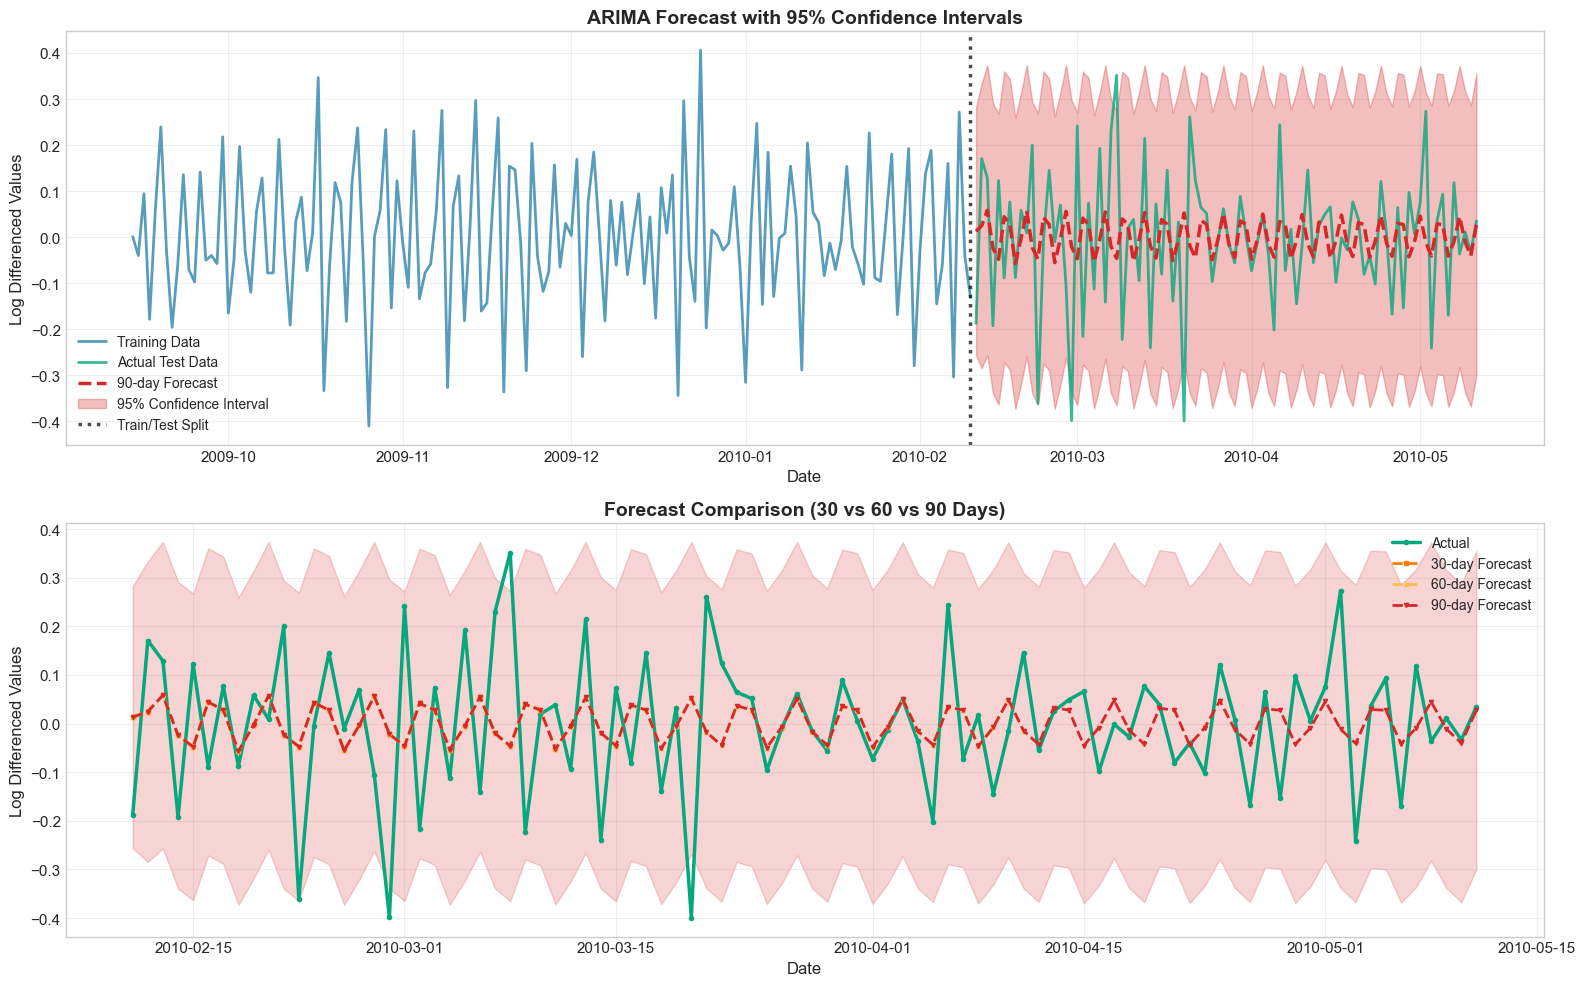

In [28]:

# ARIMA FORECASTING WITH CONFIDENCE INTERVALS
print("ARIMA FORECASTING (30, 60, 90 DAYS)")


# Generate forecast with confidence intervals
forecast_steps = 90
forecast_result = final_arima_model.get_forecast(steps=forecast_steps)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int(alpha=0.05)

# Create forecast dataframe
forecast_index = pd.date_range(start=train.index[-1] + pd.Timedelta(days=1), 
                               periods=forecast_steps, freq='D')

forecast_df = pd.DataFrame({
    'forecast': forecast_mean.values,
    'lower_95': forecast_ci.iloc[:, 0].values,
    'upper_95': forecast_ci.iloc[:, 1].values
}, index=forecast_index)

# Add 30 and 60 day markers
forecast_df['forecast_30'] = forecast_df['forecast'].copy()
forecast_df.loc[forecast_df.index[30:], 'forecast_30'] = np.nan

forecast_df['forecast_60'] = forecast_df['forecast'].copy()
forecast_df.loc[forecast_df.index[60:], 'forecast_60'] = np.nan

print(f"\n Forecast generated for {forecast_steps} days")
print(f"\n First 10 days of forecast:")
print(forecast_df[['forecast', 'lower_95', 'upper_95']].head(10))

print(f"\n Forecast summary:")
print(f"   Mean forecast value: {forecast_df['forecast'].mean():.6f}")
print(f"   Std dev of forecast: {forecast_df['forecast'].std():.6f}")
print(f"   Average CI width: {(forecast_df['upper_95'] - forecast_df['lower_95']).mean():.6f}")

# Enhanced forecast visualization
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Full forecast with confidence intervals
ax1 = axes[0]
train_plot = train[-150:]  # Last 150 days of training
test_plot = test[:90] if len(test) >= 90 else test

ax1.plot(train_plot.index, train_plot, label='Training Data', color='#2E86AB', linewidth=2, alpha=0.8)
ax1.plot(test_plot.index, test_plot, label='Actual Test Data', color='#06A77D', linewidth=2, alpha=0.8)
ax1.plot(forecast_df.index, forecast_df['forecast'], 
         label='90-day Forecast', color='#D62828', linestyle='--', linewidth=2.5)
ax1.fill_between(forecast_df.index, 
                 forecast_df['lower_95'], 
                 forecast_df['upper_95'], 
                 alpha=0.3, color='#D62828', label='95% Confidence Interval')
ax1.axvline(x=train.index[-1], color='black', linestyle=':', linewidth=2.5, 
            label='Train/Test Split', alpha=0.7)
ax1.set_title('ARIMA Forecast with 95% Confidence Intervals', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Log Differenced Values', fontsize=12)
ax1.legend(loc='best', fontsize=10, framealpha=0.9)
ax1.grid(True, alpha=0.3)

# Plot 2: Zoomed forecast period
ax2 = axes[1]
ax2.plot(test_plot.index, test_plot, label='Actual', color='#06A77D', linewidth=2.5, marker='o', markersize=3)
ax2.plot(forecast_df.index[:30], forecast_df['forecast_30'][:30], 
         label='30-day Forecast', color='#F77F00', linestyle='--', linewidth=2, marker='s', markersize=3)
ax2.plot(forecast_df.index[:60], forecast_df['forecast_60'][:60], 
         label='60-day Forecast', color='#FCBF49', linestyle='--', linewidth=2, marker='^', markersize=3)
ax2.plot(forecast_df.index, forecast_df['forecast'], 
         label='90-day Forecast', color='#D62828', linestyle='--', linewidth=2, marker='v', markersize=3)
ax2.fill_between(forecast_df.index, forecast_df['lower_95'], forecast_df['upper_95'], 
                 alpha=0.2, color='#D62828')
ax2.set_title('Forecast Comparison (30 vs 60 vs 90 Days)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Log Differenced Values', fontsize=12)
ax2.legend(loc='best', fontsize=10, framealpha=0.9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('arima_forecasts_enhanced.png', dpi=300, bbox_inches='tight')
print("\n✓ Enhanced forecast plots saved as 'arima_forecasts_enhanced.png'")
plt.show()



FORECAST EVALUATION ON TEST SET

 PERFORMANCE METRICS (First 90 days):
   MSE  (Mean Squared Error):        0.02116291
   RMSE (Root Mean Squared Error):   0.145475
   MAE  (Mean Absolute Error):       0.107502
   MAPE (Mean Absolute % Error):     157.84%
   R²   (Coefficient of Determination): -0.0294
   Direction Accuracy:               55.06%

 FORECAST ERROR ANALYSIS:
   Mean Error (Bias):      -0.001759
   Std Dev of Errors:      0.145464
   Min Error:              -0.451867
   Max Error:              0.397672

 Evaluation metrics saved to 'arima_evaluation_metrics.json'

 Evaluation plots saved as 'forecast_evaluation.png'


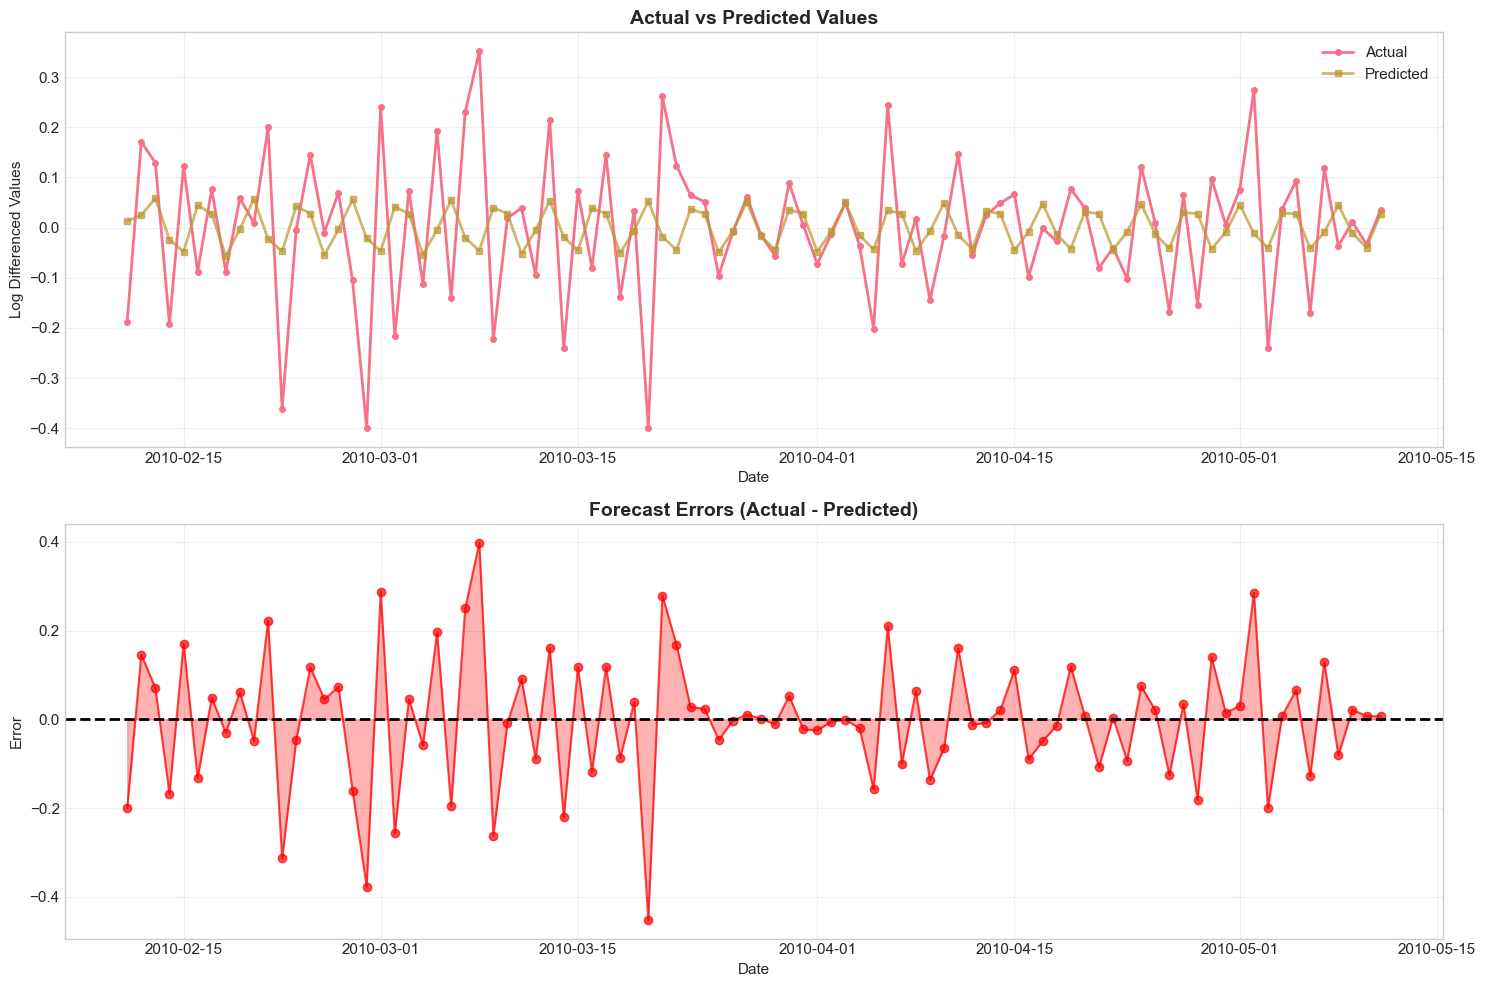

In [29]:
# FORECAST EVALUATION METRICS
print("FORECAST EVALUATION ON TEST SET")

# Calculate metrics on available test data
test_period = min(len(test), 90)
actual = test[:test_period].values
predicted = forecast_df['forecast'][:test_period].values

# Calculate comprehensive metrics
mse = mean_squared_error(actual, predicted)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual, predicted)
mape = np.mean(np.abs((actual - predicted) / (actual + 1e-10))) * 100
r2 = r2_score(actual, predicted)

# Direction accuracy
direction_actual = np.sign(np.diff(actual))
direction_pred = np.sign(np.diff(predicted))
direction_accuracy = np.mean(direction_actual == direction_pred) * 100

print(f"\n PERFORMANCE METRICS (First {test_period} days):")
print("="*50)
print(f"   MSE  (Mean Squared Error):        {mse:.8f}")
print(f"   RMSE (Root Mean Squared Error):   {rmse:.6f}")
print(f"   MAE  (Mean Absolute Error):       {mae:.6f}")
print(f"   MAPE (Mean Absolute % Error):     {mape:.2f}%")
print(f"   R²   (Coefficient of Determination): {r2:.4f}")
print(f"   Direction Accuracy:               {direction_accuracy:.2f}%")

# Residual analysis on test set
forecast_errors = actual - predicted
print(f"\n FORECAST ERROR ANALYSIS:")
print(f"   Mean Error (Bias):      {forecast_errors.mean():.6f}")
print(f"   Std Dev of Errors:      {forecast_errors.std():.6f}")
print(f"   Min Error:              {forecast_errors.min():.6f}")
print(f"   Max Error:              {forecast_errors.max():.6f}")

# Add metrics to results
evaluation_metrics = {
    'Model': f'ARIMA{best_order_aic}',
    'Test_Period': test_period,
    'MSE': mse,
    'RMSE': rmse,
    'MAE': mae,
    'MAPE': mape,
    'R2': r2,
    'Direction_Accuracy': direction_accuracy
}

# Save evaluation metrics
with open('arima_evaluation_metrics.json', 'w') as f:
    json.dump(evaluation_metrics, f, indent=4)
print("\n Evaluation metrics saved to 'arima_evaluation_metrics.json'")

# Visualize actual vs predicted
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: Actual vs Predicted
axes[0].plot(test.index[:test_period], actual, label='Actual', marker='o', linewidth=2, markersize=4)
axes[0].plot(test.index[:test_period], predicted, label='Predicted', marker='s', linewidth=2, markersize=4, alpha=0.7)
axes[0].set_title('Actual vs Predicted Values', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Log Differenced Values')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Forecast errors
axes[1].plot(test.index[:test_period], forecast_errors, marker='o', linewidth=1.5, color='red', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[1].fill_between(test.index[:test_period], 0, forecast_errors, alpha=0.3, color='red')
axes[1].set_title('Forecast Errors (Actual - Predicted)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Error')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('forecast_evaluation.png', dpi=300, bbox_inches='tight')
print("\n Evaluation plots saved as 'forecast_evaluation.png'")
plt.show()



In [30]:
# WALK-FORWARD VALIDATION
print("WALK-FORWARD VALIDATION")


print("\n Performing walk-forward validation...")
print("   Method: Rolling origin, 1-step ahead forecast")

# Walk-forward validation parameters
n_test = min(len(test), 90)
walk_forward_predictions = []
walk_forward_actual = []

print(f"   Validating on {n_test} steps...")

# Perform walk-forward
for i in range(n_test):
    # Update training set
    train_wf = pd.concat([train, test[:i]]) if i > 0 else train
    
    # Fit model
    model_wf = ARIMA(train_wf, order=best_order_aic).fit()
    
    # One-step ahead forecast
    forecast_wf = model_wf.forecast(steps=1)
    walk_forward_predictions.append(forecast_wf.iloc[0])
    walk_forward_actual.append(test.iloc[i])
    
    if (i + 1) % 20 == 0:
        print(f"   Progress: {i+1}/{n_test} steps completed")

walk_forward_predictions = np.array(walk_forward_predictions)
walk_forward_actual = np.array(walk_forward_actual)

# Calculate walk-forward metrics
wf_rmse = np.sqrt(mean_squared_error(walk_forward_actual, walk_forward_predictions))
wf_mae = mean_absolute_error(walk_forward_actual, walk_forward_predictions)
wf_mape = np.mean(np.abs((walk_forward_actual - walk_forward_predictions) / (walk_forward_actual + 1e-10))) * 100

print(f"\n Walk-forward validation completed")
print(f"\n WALK-FORWARD METRICS:")
print(f"   RMSE: {wf_rmse:.6f}")
print(f"   MAE:  {wf_mae:.6f}")
print(f"   MAPE: {wf_mape:.2f}%")

print(f"\n Comparison (Static vs Walk-Forward):")
print(f"   {'Metric':<10} {'Static':<12} {'Walk-Forward':<12} {'Difference':<12}")
print(f"   {'-'*50}")
print(f"   {'RMSE':<10} {rmse:<12.6f} {wf_rmse:<12.6f} {abs(rmse-wf_rmse):<12.6f}")
print(f"   {'MAE':<10} {mae:<12.6f} {wf_mae:<12.6f} {abs(mae-wf_mae):<12.6f}")
print(f"   {'MAPE':<10} {mape:<12.2f} {wf_mape:<12.2f} {abs(mape-wf_mape):<12.2f}")


WALK-FORWARD VALIDATION

 Performing walk-forward validation...
   Method: Rolling origin, 1-step ahead forecast
   Validating on 90 steps...
   Progress: 20/90 steps completed
   Progress: 40/90 steps completed
   Progress: 60/90 steps completed
   Progress: 80/90 steps completed

 Walk-forward validation completed

 WALK-FORWARD METRICS:
   RMSE: 0.128823
   MAE:  0.090972
   MAPE: 164.45%

 Comparison (Static vs Walk-Forward):
   Metric     Static       Walk-Forward Difference  
   --------------------------------------------------
   RMSE       0.145475     0.128823     0.016651    
   MAE        0.107502     0.090972     0.016531    
   MAPE       157.84       164.45       6.61        


GARCH(1,1) MODEL FOR VOLATILITY FORECASTING

 GARCH Model Background:
   - Captures volatility clustering (high volatility periods cluster together)
   - Models conditional variance as function of past squared errors
   - Essential for risk assessment and confidence intervals

 Residuals Statistics:
   Mean: -0.0199
   Std Dev: 13.8094
   Min: -51.9257
   Max: 53.5640

 Fitting GARCH(1,1) model...

 GARCH model fitted successfully
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4611.01
Distribution:                  Normal   AIC:                           9230.02
Method:            Maximum Likelihood   BIC:                           9250.22
                                        No. Observations:                 1152
Date:       

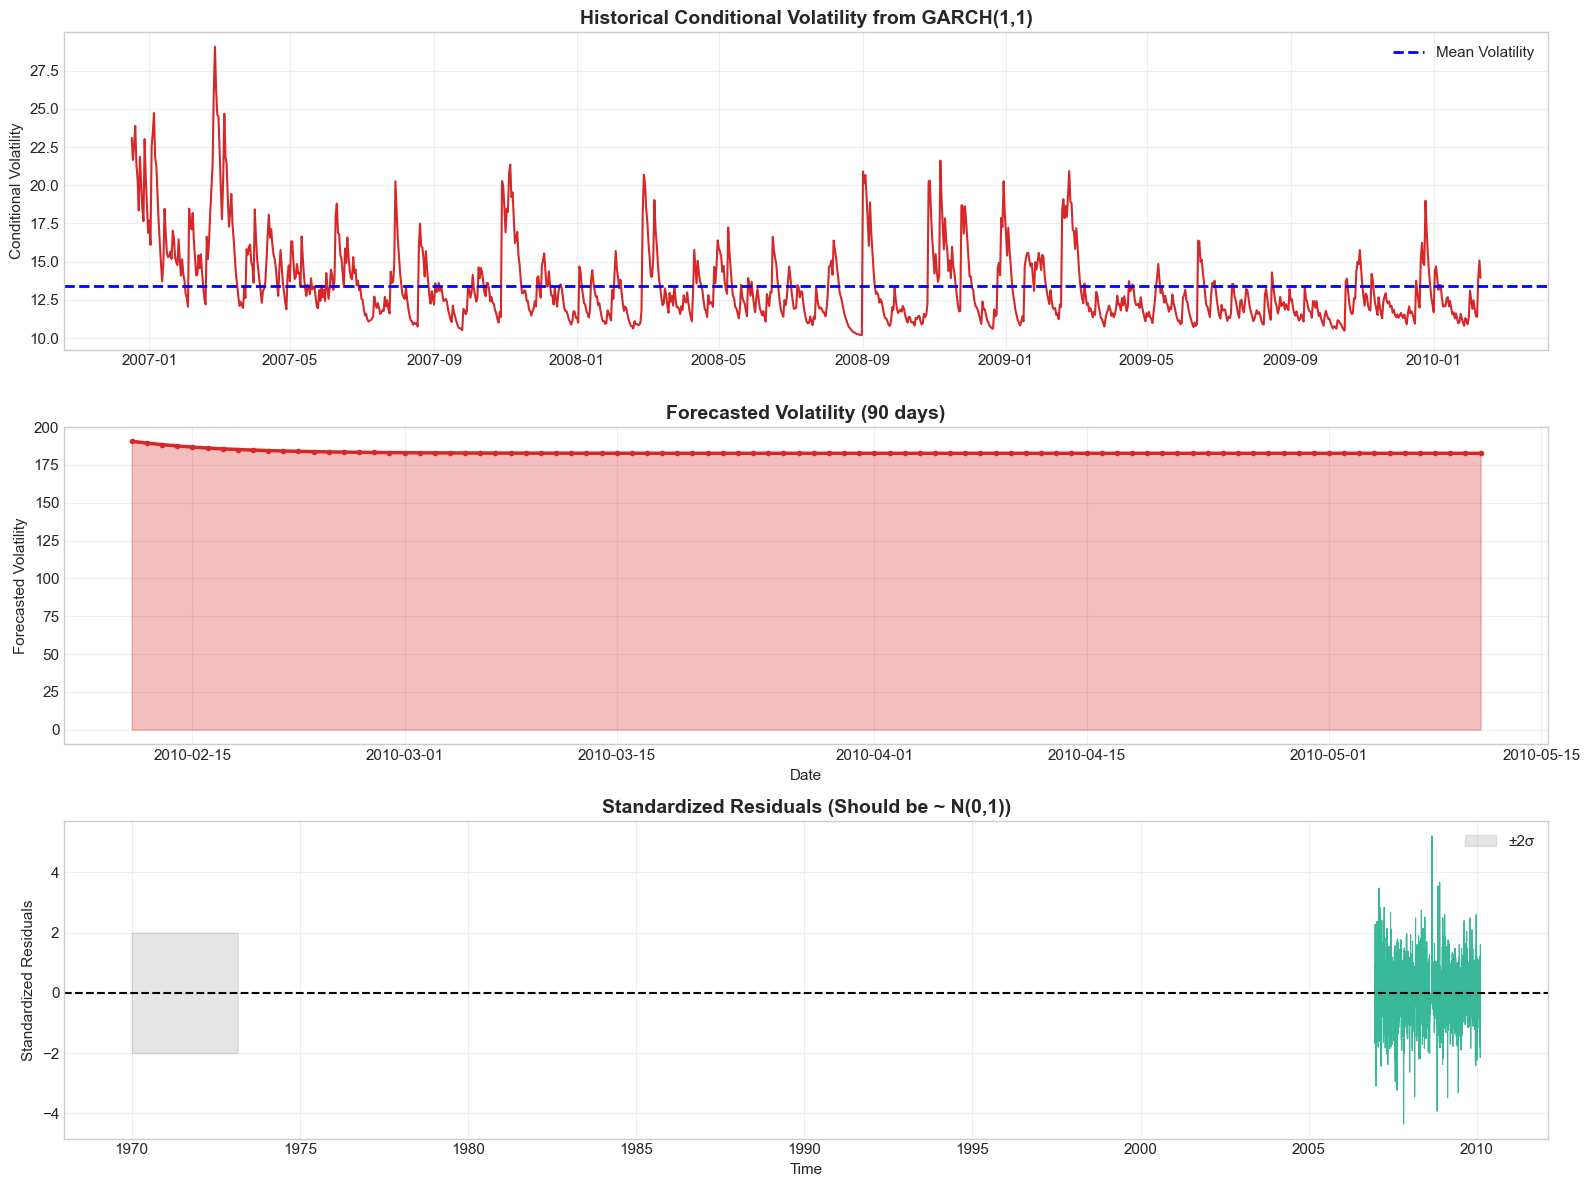

In [31]:
# GARCH MODEL FOR VOLATILITY
print("GARCH(1,1) MODEL FOR VOLATILITY FORECASTING")


print("\n GARCH Model Background:")
print("   - Captures volatility clustering (high volatility periods cluster together)")
print("   - Models conditional variance as function of past squared errors")
print("   - Essential for risk assessment and confidence intervals")

# Prepare residuals for GARCH (scale up to avoid numerical issues)
residuals_scaled = arima_residuals * 100

print(f"\n Residuals Statistics:")
print(f"   Mean: {residuals_scaled.mean():.4f}")
print(f"   Std Dev: {residuals_scaled.std():.4f}")
print(f"   Min: {residuals_scaled.min():.4f}")
print(f"   Max: {residuals_scaled.max():.4f}")

# Fit GARCH(1,1) model
print("\n Fitting GARCH(1,1) model...")
garch_model = arch_model(residuals_scaled, vol='Garch', p=1, q=1, dist='normal', rescale=False)
garch_fitted = garch_model.fit(disp='off', options={'maxiter': 1000})

print("\n GARCH model fitted successfully")

print(garch_fitted.summary())

# Extract GARCH parameters
omega = garch_fitted.params['omega']
alpha = garch_fitted.params['alpha[1]']
beta = garch_fitted.params['beta[1]']

print("\n GARCH PARAMETERS INTERPRETATION:")
print(f"   omega (ω):  {omega:.4f}  - Long-term variance component")
print(f"   alpha (α):  {alpha:.4f}  - ARCH effect (reaction to shocks)")
print(f"   beta (β):   {beta:.4f}  - GARCH effect (persistence)")
print(f"\n   Persistence (α + β): {alpha + beta:.4f}")

if alpha + beta < 1:
    print("   ✓ Stationary volatility process (α + β < 1)")
else:
    print("   Non-stationary volatility (α + β ≥ 1)")

print(f"\n   Half-life of volatility shock: {np.log(0.5)/np.log(alpha + beta):.2f} periods")

# Forecast volatility
print(f"\n Forecasting volatility for {forecast_steps} days...")
garch_forecast = garch_fitted.forecast(horizon=forecast_steps, reindex=False)
volatility_forecast = garch_forecast.variance.values[-1, :]

# Create volatility dataframe
volatility_df = pd.DataFrame({
    'volatility': volatility_forecast,
    'std_dev': np.sqrt(volatility_forecast)
}, index=forecast_index)

print(f"\n Volatility forecast completed")
print(f"\n Volatility Forecast Summary:")
print(f"   Initial volatility: {volatility_forecast[0]:.4f}")
print(f"   Final volatility: {volatility_forecast[-1]:.4f}")
print(f"   Mean volatility: {volatility_forecast.mean():.4f}")
print(f"   Change: {((volatility_forecast[-1] - volatility_forecast[0])/volatility_forecast[0]*100):.2f}%")

print(f"\n First 10 days:")
print(volatility_df.head(10))

# Enhanced GARCH visualization
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Plot 1: Conditional volatility (historical)
axes[0].plot(garch_fitted.conditional_volatility, linewidth=1.5, color='#D62828')
axes[0].set_title('Historical Conditional Volatility from GARCH(1,1)', 
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Conditional Volatility', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=garch_fitted.conditional_volatility.mean(), 
                color='blue', linestyle='--', label='Mean Volatility', linewidth=2)
axes[0].legend()

# Plot 2: Forecasted volatility
axes[1].plot(volatility_df.index, volatility_df['volatility'], 
             linewidth=2.5, color='#D62828', marker='o', markersize=3)
axes[1].fill_between(volatility_df.index, 0, volatility_df['volatility'], 
                     alpha=0.3, color='#D62828')
axes[1].set_title('Forecasted Volatility (90 days)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_ylabel('Forecasted Volatility', fontsize=11)
axes[1].grid(True, alpha=0.3)

# Plot 3: Standardized residuals
std_resid = garch_fitted.std_resid
axes[2].plot(std_resid, linewidth=0.8, alpha=0.8, color='#06A77D')
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[2].fill_between(range(len(std_resid)), -2, 2, alpha=0.2, color='gray', label='±2σ')
axes[2].set_title('Standardized Residuals (Should be ~ N(0,1))', 
                  fontsize=14, fontweight='bold')
axes[2].set_xlabel('Time', fontsize=11)
axes[2].set_ylabel('Standardized Residuals', fontsize=11)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig('garch_volatility_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ GARCH analysis plots saved as 'garch_volatility_analysis.png'")
plt.show()


In [32]:

# SAVE ALL OUTPUT FILES
print("SAVING OUTPUT FILES FOR HANDOVER")


print("\n📦 Saving files...")

# 1. ARIMA Residuals
residuals_df = pd.DataFrame({
    'DateTime': train.index,
    'residuals': arima_residuals,
    'squared_residuals': arima_residuals**2
})
residuals_df.to_csv('arima_residuals.csv', index=False)
print("   ✓ arima_residuals.csv")

# 2. ARIMA Model
with open('arima_model.pkl', 'wb') as f:
    pickle.dump(final_arima_model, f)
print("   ✓ arima_model.pkl")

# 3. ARIMA Forecast (with confidence intervals)
forecast_df.to_csv('arima_forecast.csv')
print("   ✓ arima_forecast.csv")

# 4. GARCH Predictions
volatility_df.to_csv('garch_predictions.csv')
print("   ✓ garch_predictions.csv")

# 5. GARCH Model
with open('garch_model.pkl', 'wb') as f:
    pickle.dump(garch_fitted, f)
print("   ✓ garch_model.pkl")

# 6. Model Comparison
comparison_df = pd.DataFrame(model_results)
comparison_df = comparison_df.sort_values('AIC').reset_index(drop=True)
comparison_df.to_csv('model_comparison.csv', index=False)
print("   ✓ model_comparison.csv")

# 7. Walk-forward results
wf_results = pd.DataFrame({
    'DateTime': test.index[:n_test],
    'actual': walk_forward_actual,
    'predicted': walk_forward_predictions,
    'error': walk_forward_actual - walk_forward_predictions
})
wf_results.to_csv('walk_forward_validation.csv', index=False)
print("   ✓ walk_forward_validation.csv")

# 8. Complete summary
summary_dict = {
    'model_info': model_params,
    'evaluation_metrics': evaluation_metrics,
    'walk_forward': {
        'rmse': wf_rmse,
        'mae': wf_mae,
        'mape': wf_mape
    },
    'garch_params': {
        'omega': float(omega),
        'alpha': float(alpha),
        'beta': float(beta),
        'persistence': float(alpha + beta)
    }
}

with open('complete_model_summary.json', 'w') as f:
    json.dump(summary_dict, f, indent=4)
print("   ✓ complete_model_summary.json")

print("\n✓ All files saved successfully!")


SAVING OUTPUT FILES FOR HANDOVER

📦 Saving files...
   ✓ arima_residuals.csv
   ✓ arima_model.pkl
   ✓ arima_forecast.csv
   ✓ garch_predictions.csv
   ✓ garch_model.pkl
   ✓ model_comparison.csv
   ✓ walk_forward_validation.csv
   ✓ complete_model_summary.json

✓ All files saved successfully!


In [ ]:
# GENERATE HANDOVER DOCUMENTATION
print("GENERATING HANDOVER DOCUMENTATION")

handover_doc = f"""
{'='*70}
PERSON 2 → PERSON 3 & 4: HANDOVER DOCUMENTATION
{'='*70}

📅 Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
👤 Author: Person 2 (ARIMA + GARCH Implementation)

{'='*70}
1. MODEL SUMMARY
{'='*70}

✓ Final Model: ARIMA{best_order_aic} + GARCH(1,1)

ARIMA Parameters:
  - Order: {best_order_aic}
  - AIC: {best_aic:.4f}
  - BIC: {best_bic:.4f}
  - Training observations: {len(train)}

GARCH Parameters:
  - omega (ω): {omega:.4f}
  - alpha (α): {alpha:.4f}
  - beta (β): {beta:.4f}
  - Persistence: {alpha + beta:.4f}

{'='*70}
2. PERFORMANCE METRICS
{'='*70}

Static Forecast (90 days):
  - RMSE: {rmse:.6f}
  - MAE: {mae:.6f}
  - MAPE: {mape:.2f}%
  - R²: {r2:.4f}
  - Direction Accuracy: {direction_accuracy:.2f}%

Walk-Forward Validation:
  - RMSE: {wf_rmse:.6f}
  - MAE: {wf_mae:.6f}
  - MAPE: {wf_mape:.2f}%

{'='*70}
3. KEY FILES FOR PERSON 3 (LSTM)
{'='*70}

Primary Files:
  📄 final_time_series.csv      → Original stationary data for LSTM training
  📄 arima_residuals.csv         → ARIMA residuals (non-linear patterns)
  📄 arima_forecast.csv          → ARIMA baseline predictions
  📄 walk_forward_validation.csv → Validation results

Supporting Files:
  📄 arima_model_params.json     → Model configuration
  📄 arima_evaluation_metrics.json → Performance benchmarks
  📊 acf_pacf_plots.png          → Autocorrelation analysis
  📊 seasonality_check.png       → Seasonal pattern analysis

{'='*70}
4. KEY FILES FOR PERSON 4 (HYBRID)
{'='*70}

Essential Files:
  🔧 arima_model.pkl             → Trained ARIMA model
  🔧 garch_model.pkl             → Trained GARCH model
  📄 arima_forecast.csv          → ARIMA predictions
  📄 garch_predictions.csv       → Volatility forecasts
  📄 arima_residuals.csv         → For hybrid modeling

You'll also need LSTM forecasts from Person 3!

{'='*70}
5. DATA CHARACTERISTICS
{'='*70}

Training Set:
  - Period: {train.index[0].date()} to {train.index[-1].date()}
  - Observations: {len(train)}
  - Mean: {train.mean():.6f}
  - Std Dev: {train.std():.6f}

Test Set:
  - Period: {test.index[0].date()} to {test.index[-1].date()}
  - Observations: {len(test)}
  - Mean: {test.mean():.6f}
  - Std Dev: {test.std():.6f}

Stationarity: ✓ Confirmed (log-differenced data)
Seasonality: ⊘ Not significant (checked - see seasonality_check.png)

{'='*70}
6. RECOMMENDATIONS FOR PERSON 3 (LSTM)
{'='*70}

Suggested LSTM Architecture:
  - Input shape: (look_back, 1) → Try 30-60 timesteps
  - LSTM layers: 2-3 layers with 50-100 units each
  - Dropout: 0.2-0.3 to prevent overfitting
  - Activation: tanh (default) or relu
  - Optimizer: Adam with learning rate 0.001
  - Loss: MSE or MAE
  - Batch size: 32-64
  - Epochs: 50-100 with early stopping

Training Tips:
  ✓ Use first 80% for training, last 20% for validation
  ✓ Normalize/scale data (MinMaxScaler or StandardScaler)
  ✓ Implement early stopping (patience=10-15)
  ✓ Use ReduceLROnPlateau for learning rate scheduling
  ✓ Save best model based on validation loss

Expected Performance:
  - Target RMSE: < {rmse:.6f} (beat ARIMA baseline)
  - Target MAPE: < {mape:.2f}%
  - LSTM should capture non-linear patterns ARIMA missed

{'='*70}
7. RECOMMENDATIONS FOR PERSON 4 (HYBRID)
{'='*70}

Hybrid Model Architectures to Try:

Option 1: Sequential (ARIMA → LSTM)
  1. Use ARIMA for linear component
  2. Train LSTM on ARIMA residuals (non-linear)
  3. Final = ARIMA_forecast + LSTM_residual_forecast

Option 2: Parallel Ensemble
  1. ARIMA forecast independently
  2. LSTM forecast independently
  3. Weighted: w1*ARIMA + w2*LSTM (optimize w1, w2)

Option 3: ARIMA-GARCH-LSTM (Most Complex)
  1. ARIMA captures trend
  2. GARCH captures volatility
  3. LSTM captures complex residuals
  4. Combine all three

Expected Performance:
  - Hybrid should outperform both ARIMA and LSTM individually
  - Target improvement: 10-20% over best individual model
  - Should handle both linear trends and non-linear patterns

{'='*70}
8. KNOWN LIMITATIONS & WARNINGS
{'='*70}

⚠️ ARIMA Limitations:
  - Assumes linear relationships
  - Long-term forecasts converge to mean (see plots)
  - Cannot capture regime changes or structural breaks
  - Fixed parameters (no adaptation)

⚠️ Data Warnings:
  - Some autocorrelation remains in residuals (Ljung-Box test)
  - ARCH effects detected → GARCH is necessary
  - Heavy tails in residual distribution (Kurtosis > 3)
  - {outliers} outliers detected ({outliers/len(df)*100:.2f}%)

⚠️ Forecast Uncertainty:
  - Confidence intervals widen over time
  - 90-day forecasts have high uncertainty
  - Consider ensemble methods to improve reliability

{'='*70}
9. VERIFICATION CHECKLIST
{'='*70}

Before using these files, verify:
  ☐ All CSV files load without errors
  ☐ Pickle files can be loaded: pickle.load(open('file.pkl', 'rb'))
  ☐ No missing values in forecast files
  ☐ Date indices align properly
  ☐ Residuals have mean ≈ 0
  ☐ Volatility values are all positive
  ☐ Model parameters in JSON files are readable

{'='*70}
10. CONTACT & QUESTIONS
{'='*70}

If you have questions about:
  - Model selection → See model_comparison.csv (25 models tested)
  - Diagnostics → See arima_residual_diagnostics.png
  - Performance → See complete_model_summary.json
  - Methodology → Review this script's comments

Good luck with LSTM and Hybrid implementations! 🚀

{'='*70}
END OF HANDOVER DOCUMENTATION
{'='*70}
"""

with open('HANDOVER_TO_PERSON3_AND_4.txt', 'w') as f:
    f.write(handover_doc)

print("\n✓ Handover documentation saved as 'HANDOVER_TO_PERSON3_AND_4.txt'")



GENERATING HANDOVER DOCUMENTATION

✓ Handover documentation saved as 'HANDOVER_TO_PERSON3_AND_4.txt'


In [ ]:

# FINAL SUMMARY
print("FINAL SUMMARY REPORT")
print(f"""
✅ ARIMA MODEL: ARIMA{best_order_aic}
   - AIC: {best_aic:.4f}
   - BIC: {best_bic:.4f}
   - Test RMSE: {rmse:.6f}
   - Test MAPE: {mape:.2f}%
  
✅ GARCH MODEL: GARCH(1,1)
   - Fitted on ARIMA residuals
   - Volatility persistence: {alpha + beta:.4f}
   - 90-day volatility forecast generated
  
✅ FORECASTS GENERATED:
   - 90-day point forecasts with 95% CI
   - Walk-forward validation completed
   - Multiple evaluation metrics calculated
  
✅ OUTPUT FILES (15 files total):
   Core Files:
   1.  arima_residuals.csv
   2.  arima_model.pkl
   3.  arima_forecast.csv
   4.  garch_predictions.csv
   5.  garch_model.pkl
   
   Analysis Files:
   6.  model_comparison.csv
   7.  walk_forward_validation.csv
   8.  arima_model_params.json
   9.  arima_evaluation_metrics.json
   10. complete_model_summary.json
   
   Visualization Files:
   11. acf_pacf_plots.png
   12. seasonality_check.png
   13. arima_residual_diagnostics.png
   14. arima_forecasts_enhanced.png
   15. forecast_evaluation.png
   16. garch_volatility_analysis.png

""")

FINAL SUMMARY REPORT

✅ ARIMA MODEL: ARIMA(2, 0, 4)
   - AIC: -1282.5094
   - BIC: -1242.1153
   - Test RMSE: 0.145475
   - Test MAPE: 157.84%
  
✅ GARCH MODEL: GARCH(1,1)
   - Fitted on ARIMA residuals
   - Volatility persistence: 0.8480
   - 90-day volatility forecast generated
  
✅ FORECASTS GENERATED:
   - 90-day point forecasts with 95% CI
   - Walk-forward validation completed
   - Multiple evaluation metrics calculated
  
✅ OUTPUT FILES (15 files total):
   Core Files:
   1.  arima_residuals.csv
   2.  arima_model.pkl
   3.  arima_forecast.csv
   4.  garch_predictions.csv
   5.  garch_model.pkl
   
   Analysis Files:
   6.  model_comparison.csv
   7.  walk_forward_validation.csv
   8.  arima_model_params.json
   9.  arima_evaluation_metrics.json
   10. complete_model_summary.json
   
   Visualization Files:
   11. acf_pacf_plots.png
   12. seasonality_check.png
   13. arima_residual_diagnostics.png
   14. arima_forecasts_enhanced.png
   15. forecast_evaluation.png
   16. garch_v